# Chronic Kidney Disease Classification from Blood and Urine Markers

Exploratory Python project applying machine learning to routine
laboratory and clinical markers to distinguish CKD from non-CKD patients.

Dataset: UCI Chronic Kidney Disease Dataset
https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

Nelly Oruwari


In [1]:
!pip install ucimlrepo

Importing tool for assessment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


Loading dataset from repository and cleaning

In [3]:
# Loading data from repository
from ucimlrepo import fetch_ucirepo
ckd = fetch_ucirepo(id=336)
X = ckd.data.features.copy()
y_raw = ckd.data.targets.iloc[:, 0].astype(str).str.strip()
print(X.shape)
X.head()

(400, 24)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no


Visuals of the bottom of the table.

In [4]:
X.tail(6)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
394,50.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,137.0,...,14.1,45.0,9500.0,4.6,no,no,no,good,no,no
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,15.7,47.0,6700.0,4.9,no,no,no,good,no,no
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,16.5,54.0,7800.0,6.2,no,no,no,good,no,no
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,15.8,49.0,6600.0,5.4,no,no,no,good,no,no
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,14.2,51.0,7200.0,5.9,no,no,no,good,no,no
399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,131.0,...,15.8,53.0,6800.0,6.1,no,no,no,good,no,no


Encoding diagnosis as numbers, CKD = 1 and NotCKD = 0

In [5]:
y = y_raw.map ({"ckd": 1, "notckd": 0})
print(y.value_counts(dropna=False))

class
1    250
0    150
Name: count, dtype: int64


In [6]:
# 150 patients have CKD, about 37.5%, and 250 with chronic kidney disease (62.5%), amounting to 400 total patients in the data.

Removing placeholders and empty spaces to assess actual missing values (NaN) per column

In [7]:
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].astype(str).str.strip().replace({"?": np.nan, "nan": np.nan, "": np.nan})
        converted = pd.to_numeric(X[col], errors="coerce")
        if converted.notna().sum() >= 0.9 * X[col].notna().sum():
            X[col] = converted

numeric_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print(X.isna().sum().sort_values(ascending=False))

Numeric: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Categorical: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
rbc      152
rbcc     131
wbcc     106
pot       88
sod       87
pcv       71
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
pcc        4
ba         4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64


In [8]:
# The above shows the number of missing values per clinical parameter. The missingness ranges from under 1 - 38%, with rbc,rbcc,and wbcc having the most missing values at 38%,33%,and 27% respectively showing.

Checking the frequency of NaN in 3 columns for the first 15 patients.

In [9]:
X[["hemo", "rbc", "sc"]].head(15)

,hemo,rbc,sc
0,15.4,NaN,1.2
1,11.3,NaN,0.8
2,9.6,normal,1.8
3,11.2,normal,3.8
4,11.6,normal,1.4
5,12.2,NaN,1.1
6,12.4,NaN,24.0
7,12.4,normal,1.1
8,10.8,normal,1.9
9,9.5,abnormal,7.2


Comparing three key markers between patients without and with CKD.

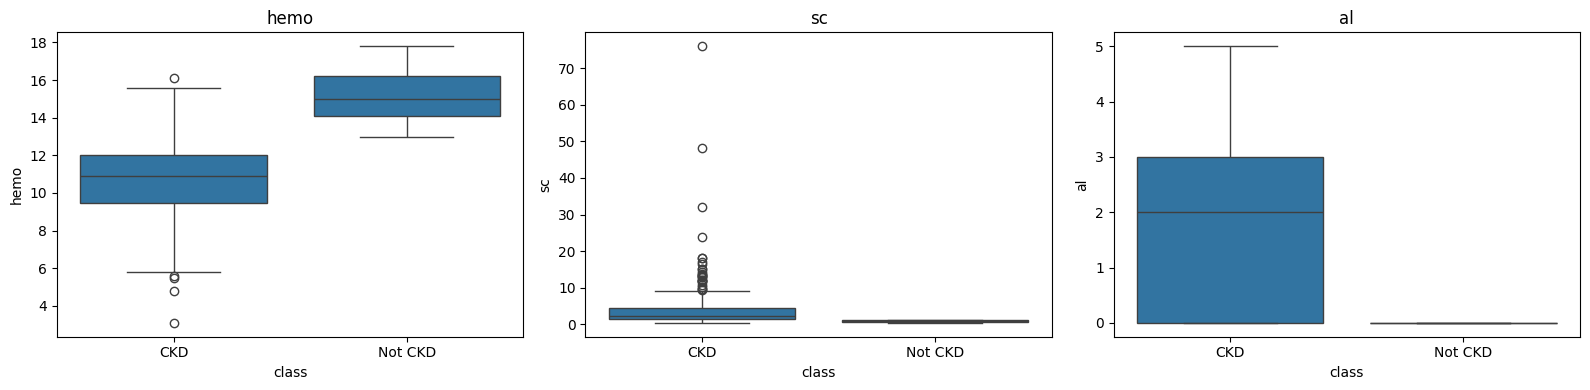

In [10]:
labels = y.map({0: "Not CKD", 1: "CKD"})
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["hemo", "sc", "al"]):
    sns.boxplot(x=labels, y=X[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("markers_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# From the output above, the hemoglobin in patients with CKD are low in comparison to the group without, Not-CKD. There is a large portion of individuals with lower hb compared to higher hb in Not-CKD group, with a median of 11g/dL, which is consistent with anaemia in CKD.Because of the known build up of creatinine in the blood when there is impairment in kidney fileration, the SC-serum creatinine shows significant increase in the blood. There is a high number of individual observations made on patients with high creatinine, and in comparison with non-CKD there is normal creatinine levels, around 1mg/dL. The CKD group is right-skewed with extreme outliers due to severe cases or date entry errors. Albumin measured using dipsticks in urine, shows majority of patients within the CKD group have a moderate amount of protein in urine, roughly about 2+, in comparison with those with high albumin in the CKD group. Meaning, only 25% of patients exhibit moderate protein levels, despite being in the CKD group, which is not strong enough to identify CKD alone.

Splitting the data, 80% for training, and 20% set aside as test. This is to prevent leaking from the train group into test group. The test set will not be used until final evaluation.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

Filling missing numbers with the estimated median of training set into tests patient's gaps, and missing categories with the most common value, converting categories into 0 or 1.

In [13]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)])

Comparing models: Logistics regression and Random forests

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=5,
                            scoring=["recall", "precision", "roc_auc"])
    print(name)
    print("  Recall:   ", scores["test_recall"].mean().round(3))
    print("  Precision:", scores["test_precision"].mean().round(3))
    print("  ROC AUC:  ", scores["test_roc_auc"].mean().round(3))

Logistic Regression
  Recall:    0.99
  Precision: 0.995
  ROC AUC:   1.0
Random Forest
  Recall:    0.995
  Precision: 0.985
  ROC AUC:   1.0


In [15]:
# Determined the proportion of true CKD cases. The logistic regression analysis and random forest both shared a close range of CKD predicted cases with an accuracy of 0.995 and 0.985. ROC-AUC is 1.0 which denotes the accuracy of the model to differentiate between CKD and NotCKD.

Testing the trained model on the the test data (20%).

              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



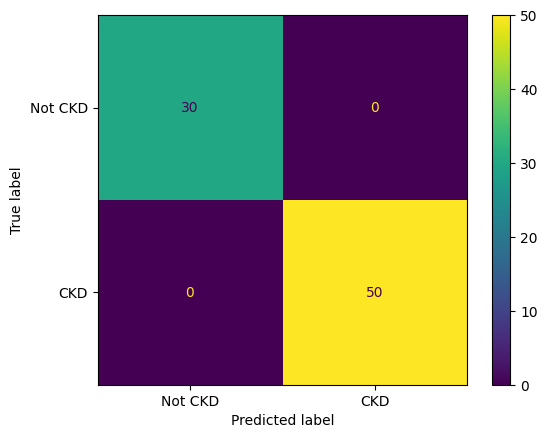

In [16]:
final = Pipeline([("prep", preprocess),
                  ("model", RandomForestClassifier(n_estimators=200, random_state=42))])
final.fit(X_train, y_train)
pred = final.predict(X_test)
print(classification_report(y_test, pred, target_names=["Not CKD", "CKD"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Not CKD", "CKD"])
plt.savefig("final_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# From the confusion matrix generated the test group had a total of 80 randomly chosen patients from both groups. The model accurately classified all patients with 0 FP and FN. It predicted correctly patients with CKD while determinining those without.Accuracy is 1.0 meaning that the model worked accurately.

Identifying parameters that drove the model to its predictions.

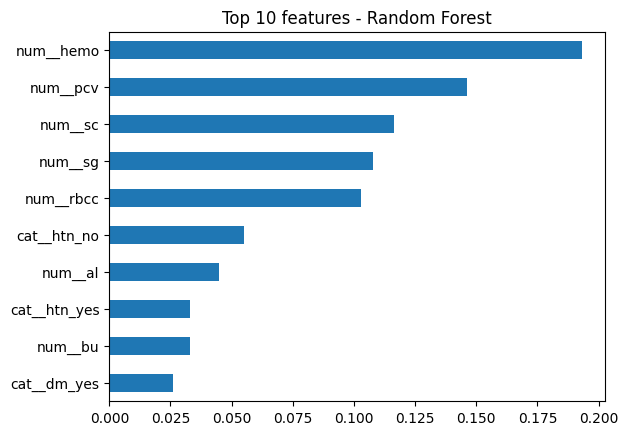

In [18]:
names = final.named_steps["prep"].get_feature_names_out()
importances = pd.Series(final.named_steps["model"].feature_importances_, index=names)
importances.sort_values(ascending=False).head(10).sort_values().plot(kind="barh")
plt.title("Top 10 features - Random Forest")
plt.savefig("top_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# The clinical parameters that helped the models predictions most are hemoglobin levels, pcv volume, serum creatinine, specific gravity of urine samples, and red blood cell count. In CKD cases there is a high association of increased serum creatinine in the blood as a result of impaired kidney filteration. Three of the top five (haemoglobin, PCV, RBC count) reflect anaemia: healthy kidneys produce erythropoietin, which stimulates red cell production in the bone marrow, and in CKD this falls. Because these three are correlated, they share importance. This importance is only an association and not the cause.

######The clinical parameters that helped the models predictions most are hemoglobin levels, pcv volume, serum creatinine, specific gravity of urine samples, and red blood cell count. In CKD cases there is a high association of increased serum creatinine in the blood as a result of impaired kidney filteration. Three of the top five (haemoglobin, PCV, RBC count) reflect anaemia: healthy kidneys produce erythropoietin, which stimulates red cell production in the bone marrow, and in CKD this falls. Because these three are correlated, they share importance. This importance is only an association and not the cause.

**Conclusion and Limitations**



1.   Linear regression and the random forest models performed very well as classifiers for CKD and Not-CKD.
2.   This is a small single source dataset and there is no external validation.
1.   There is alot of missing data filled by median and mode imputation.
2.   CKD is over-represented compared with the general population.
1.   This project is only an exploratory model and not a diagnostic tool.






